In [8]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [10]:
# Load the dataset
df = pd.read_csv('../data/NYC_Taxi_ABT.csv')

Net Revenue per Hour Quantiles:
0.010     $31.13
0.050     $59.18
0.250     $77.37
0.500     $92.96
0.750    $115.66
0.900    $148.04
0.950    $175.21
0.990    $252.89
0.999    $537.35
Name: net_revenue_per_hour, dtype: str

99th percentile cap for readable plotting: $252.89


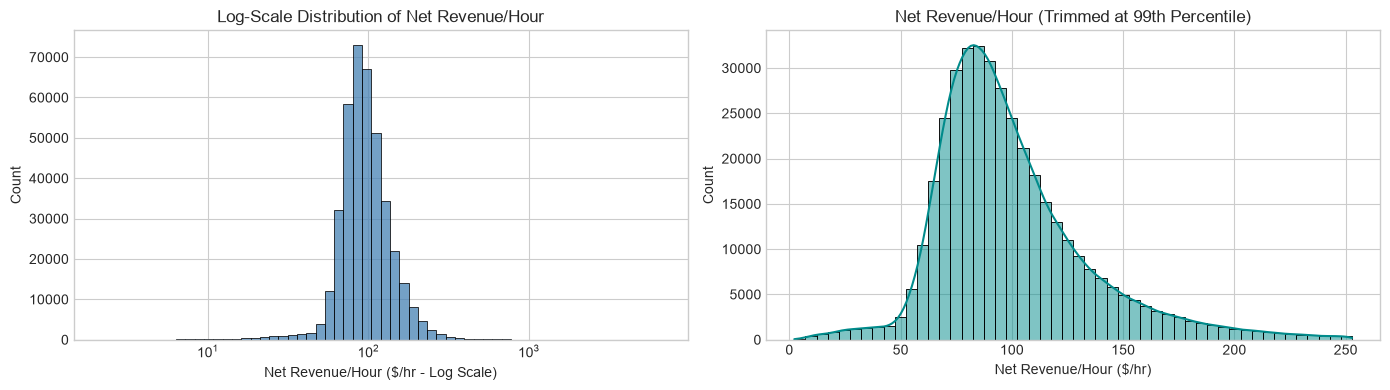

In [ ]:
# Sample 10% for fast visualization
eda_df = df.sample(frac=0.10, random_state=42).copy()

# Inspect distribution quantiles for net_revenue_per_hour
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
print("Net Revenue per Hour Quantiles:")
print(eda_df['net_revenue_per_hour'].quantile(quantiles).apply(lambda x: f"${x:,.2f}"))

# Identify upper threshold for plotting to handle extreme trip outliers
cap_value = eda_df['net_revenue_per_hour'].quantile(0.99)
print(f"\n99th percentile cap for readable plotting: ${cap_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
sns.histplot(eda_df['net_revenue_per_hour'], bins=60, log_scale=True, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Scale Distribution of Net Revenue/Hour')
axes[0].set_xlabel('Net Revenue/Hour ($/hr - Log Scale)')

# Filtered distribution
sns.histplot(eda_df[eda_df['net_revenue_per_hour'] <= cap_value]['net_revenue_per_hour'], 
             bins=50, kde=True, ax=axes[1], color='darkcyan')
axes[1].set_title('Net Revenue/Hour (Trimmed at 99th Percentile)')
axes[1].set_xlabel('Net Revenue/Hour ($/hr)')

plt.tight_layout()
plt.show()

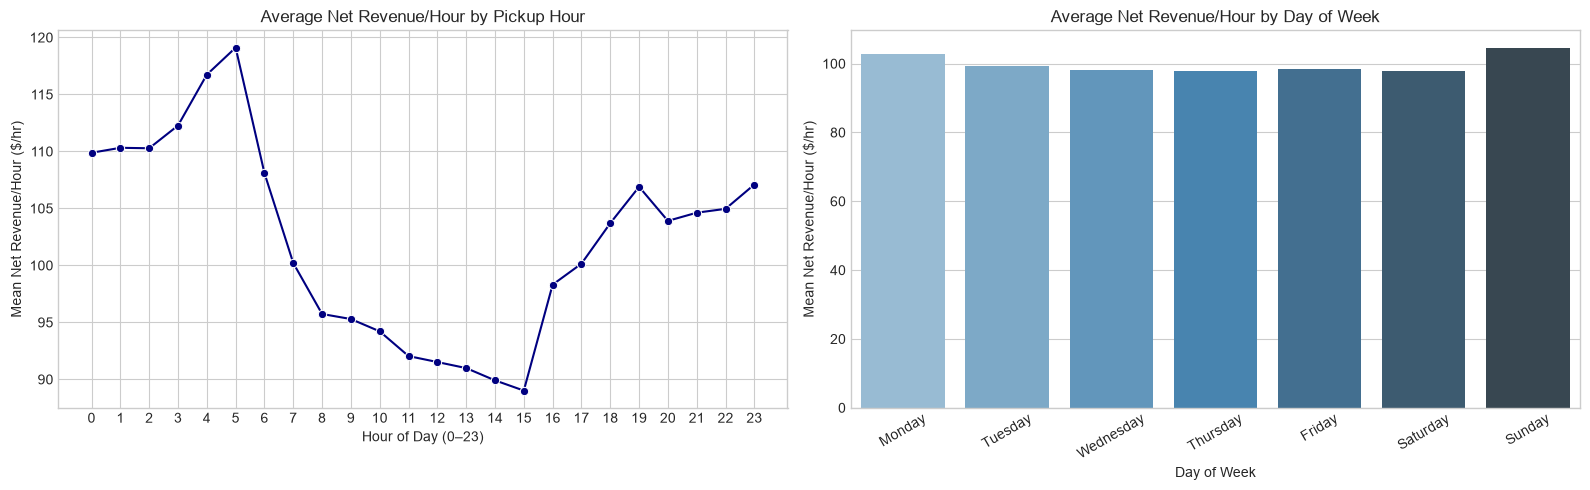

In [ ]:
# Trimmed dataframe for clear charts
viz_df = eda_df[eda_df['net_revenue_per_hour'] <= cap_value]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Hourly trends
hourly_agg = viz_df.groupby('pickup_hour')['net_revenue_per_hour'].mean().reset_index()
sns.lineplot(data=hourly_agg, x='pickup_hour', y='net_revenue_per_hour', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Average Net Revenue/Hour by Pickup Hour')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_xticks(range(0, 24))

# 2. Day of Week trends
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_agg = viz_df.groupby('day_of_week')['net_revenue_per_hour'].mean().reindex(weekday_order).reset_index()
sns.barplot(data=day_agg, x='day_of_week', y='net_revenue_per_hour', palette='Blues_d', ax=axes[1])
axes[1].set_title('Average Net Revenue/Hour by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

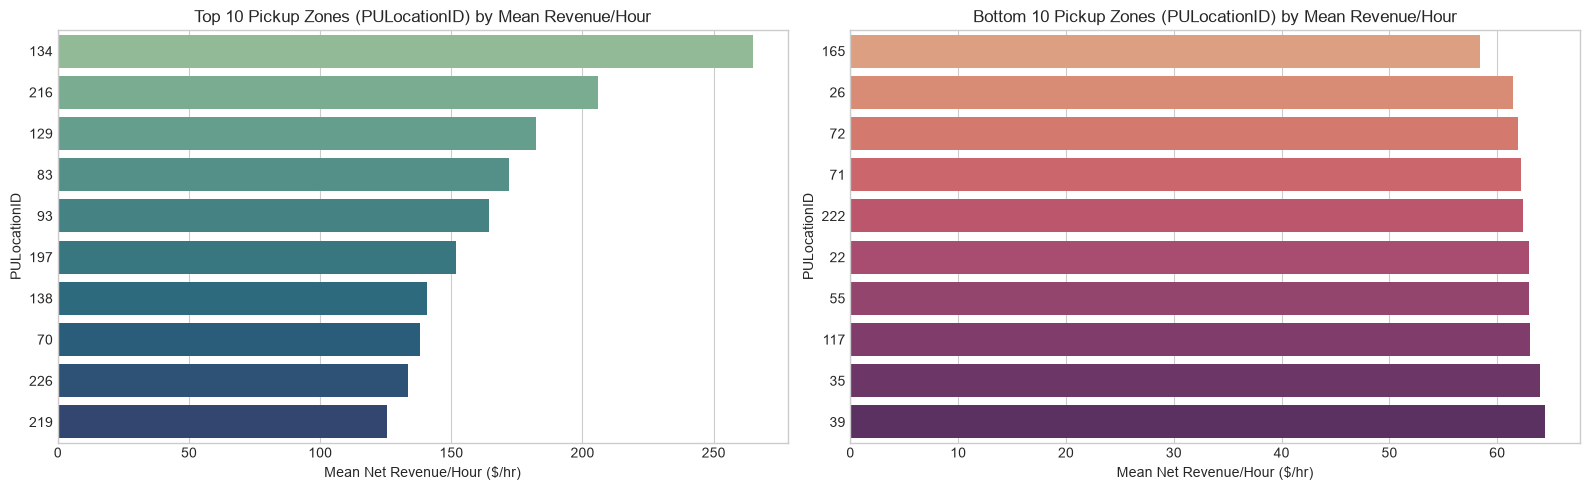

In [ ]:
# Compute mean revenue and trip volume per zone
zone_stats = eda_df.groupby('PULocationID').agg(
    mean_revenue=('net_revenue_per_hour', 'mean'),
    trip_count=('net_revenue_per_hour', 'count')
).reset_index()

# Keep zones with sufficient support
zone_stats_filtered = zone_stats[zone_stats['trip_count'] >= 50]

top_10 = zone_stats_filtered.nlargest(10, 'mean_revenue')
bottom_10 = zone_stats_filtered.nsmallest(10, 'mean_revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_10, x='mean_revenue', y=top_10['PULocationID'].astype(str), 
            palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[0].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_ylabel('PULocationID')

sns.barplot(data=bottom_10, x='mean_revenue', y=bottom_10['PULocationID'].astype(str), 
            palette='flare', ax=axes[1])
axes[1].set_title('Bottom 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[1].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('PULocationID')

plt.tight_layout()
plt.show()

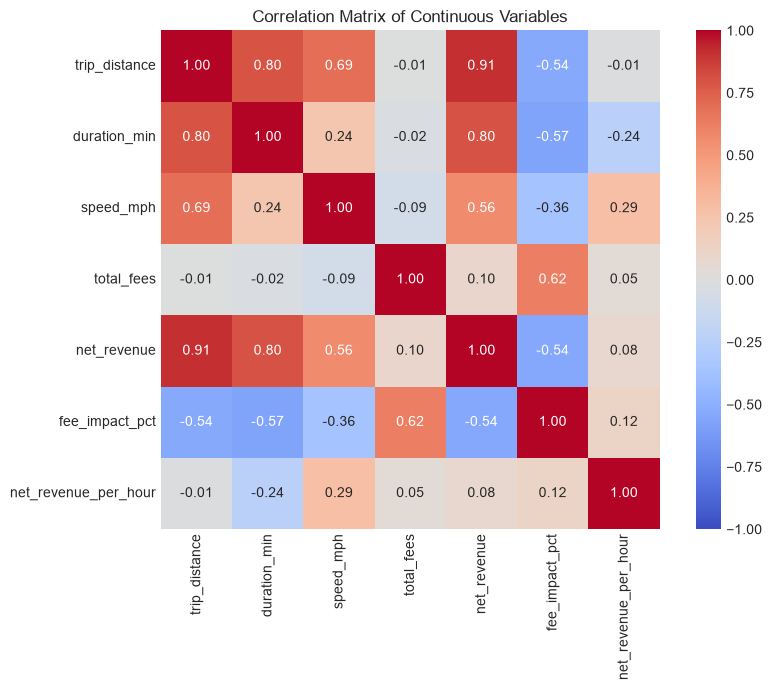

In [ ]:
# Numerical variables
num_cols = [
    'trip_distance', 'duration_min', 'speed_mph', 
    'total_fees', 'net_revenue', 'fee_impact_pct', 
    'net_revenue_per_hour'
]

corr_matrix = eda_df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()